In [ ]:
from pathlib import Path

# path setting
BASE_PATH = Path.cwd().parent.parent

RAW = BASE_PATH / 'Data' / 'raw'
TEMP = BASE_PATH / 'Data' / 'temp'
USE = BASE_PATH / 'Data' / 'use'
FIGURES = BASE_PATH / 'Results' / 'Figures'
TABLES = BASE_PATH / 'Results' / 'Tables'

for path in [RAW, TEMP, USE, FIGURES, TABLES]:
    path.mkdir(parents=True, exist_ok=True)

print(f"✅ BASE_PATH: {BASE_PATH}")


In [ ]:
# Figure 1. Global data center distribution and growth trends.
# a, Geographical distribution of data centers by country. 
# b, Annual new installations by country and data center type from 2000 to 2024. 

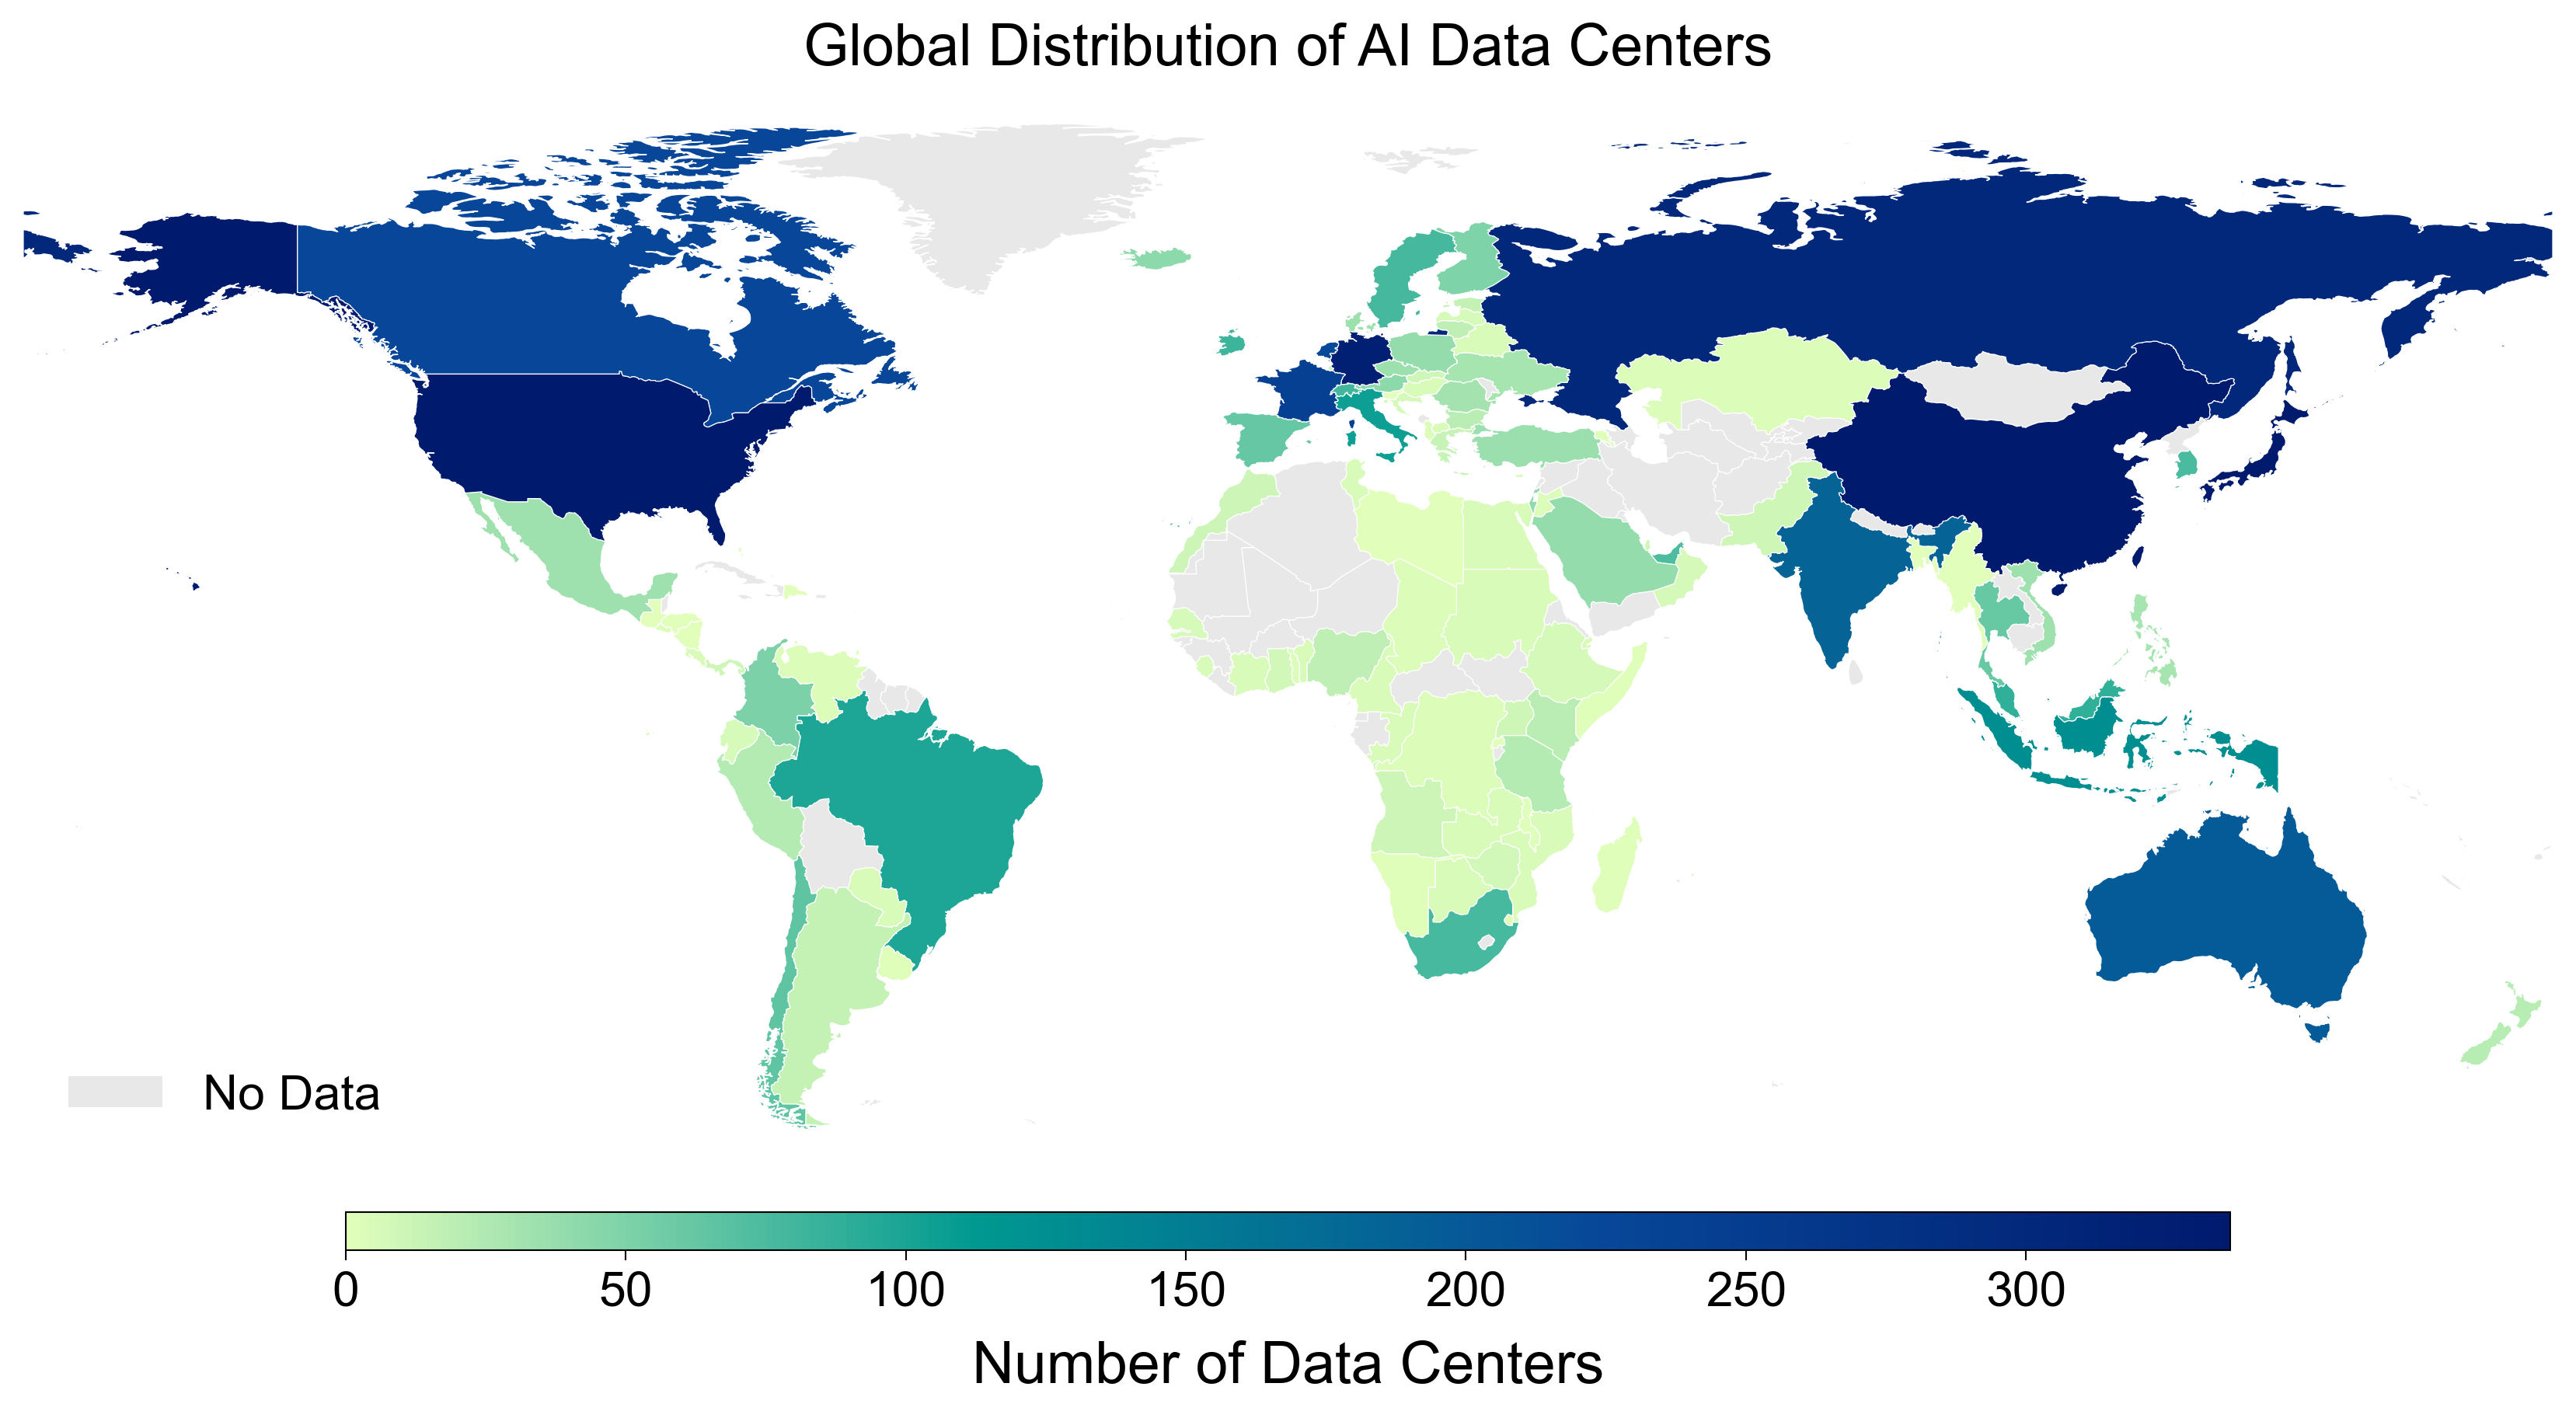


Data Filtering Summary
Total data centers after filtering: 9031
Countries/territories with data centers: 126

Top 10 countries/territories by number of data centers after HKG/MAC/TWN aggregation:
Alpha-3 code  count
         USA   2522
         CHN   1595
         JPN    458
         GBR    342
         DEU    323
         RUS    302
         FRA    241
         CAN    227
         NLD    222
         AUS    196

French Guiana map-code check:
iso_a3 parent_iso_a3          name       GEOUNIT  ADMIN     TYPE         FCLASS_ISO  count
   GUF           FRA French Guiana French Guiana France Geo unit Admin-0 dependency    0.0

Overseas/dependent territories with positive raw data-center counts:
iso_a3 parent_iso_a3 GU_A3          name        NAME_LONG          GEOUNIT            ADMIN  SOVEREIGNT       TYPE         FCLASS_ISO  count
   CUW           CUW   CUW       Curaçao          Curaçao          Curaçao          Curaçao Netherlands    Country Admin-0 dependency    2.0
   PYF           P

In [19]:
# Fig. 1a. Geographical distribution of data centers by country/territory
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.linewidth': 0.5,
})

# -----------------------------
# 1. Read and clean data
# -----------------------------

df_centers = pd.read_excel(os.path.join(RAW, 'SPGlobal_Export.xlsx'), sheet_name='Sheet1')
df_country = pd.read_excel(os.path.join(RAW, 'SPGlobal_Export.xlsx'), sheet_name='country')

df_centers = df_centers[
    (df_centers['YR_BUILT'].notna()) &
    (df_centers['LATITUDE'].notna()) &
    (df_centers['LONGITUDE'].notna()) &
    (df_centers['YR_BUILT'] != 2025)
].copy()

df_merged = df_centers.merge(
    df_country[['COUNTRY', 'Alpha-3 code', 'Region']],
    on='COUNTRY',
    how='left'
)

country_counts = (
    df_merged
    .groupby('Alpha-3 code', dropna=False)
    .size()
    .reset_index(name='count')
)

country_counts = country_counts[country_counts['Alpha-3 code'].notna()].copy()

# -----------------------------
# 2. Merge Hong Kong, Taiwan, and Macau into China
# -----------------------------

hkg_count = country_counts.loc[country_counts['Alpha-3 code'] == 'HKG', 'count'].sum()
twn_count = country_counts.loc[country_counts['Alpha-3 code'] == 'TWN', 'count'].sum()
mac_count = country_counts.loc[country_counts['Alpha-3 code'] == 'MAC', 'count'].sum()

china_extra_count = hkg_count + twn_count + mac_count

if 'CHN' in country_counts['Alpha-3 code'].values:
    country_counts.loc[country_counts['Alpha-3 code'] == 'CHN', 'count'] += china_extra_count
else:
    country_counts = pd.concat([
        country_counts,
        pd.DataFrame({
            'Alpha-3 code': ['CHN'],
            'count': [china_extra_count]
        })
    ], ignore_index=True)

country_counts.loc[
    country_counts['Alpha-3 code'].isin(['HKG', 'MAC', 'TWN']),
    'count'
] = 0

# -----------------------------
# 3. Read Natural Earth map units
#    Use territory-specific ISO_A3, not parent ADM0_A3
# -----------------------------

url = "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_map_units.zip"
world_raw = gpd.read_file(url).copy()

# Preserve parent-country code for diagnostics
if 'ADM0_A3' in world_raw.columns:
    world_raw = world_raw.rename(columns={'ADM0_A3': 'parent_iso_a3'})

# Use territory-specific ISO_A3 when available.
# This prevents overseas territories such as French Guiana from inheriting France's count.
if 'ISO_A3' in world_raw.columns:
    world_raw = world_raw.rename(columns={'ISO_A3': 'iso_a3'})
elif 'GU_A3' in world_raw.columns:
    world_raw = world_raw.rename(columns={'GU_A3': 'iso_a3'})
elif 'parent_iso_a3' in world_raw.columns:
    world_raw = world_raw.rename(columns={'parent_iso_a3': 'iso_a3'})
else:
    raise ValueError("No usable ISO code column found in Natural Earth map units.")

if 'NAME' in world_raw.columns:
    world_raw = world_raw.rename(columns={'NAME': 'name'})

world_raw = world_raw[world_raw['iso_a3'].notna()].copy()
world_raw = world_raw[world_raw['iso_a3'] != '-99'].copy()

# Keep useful diagnostic columns if available
diagnostic_cols = [
    c for c in [
        'iso_a3', 'parent_iso_a3', 'GU_A3', 'name', 'NAME_LONG',
        'GEOUNIT', 'ADMIN', 'SOVEREIGNT', 'TYPE', 'FCLASS_ISO'
    ]
    if c in world_raw.columns
]

# -----------------------------
# 4. Dissolve map units by territory-specific ISO_A3
# -----------------------------

keep_cols = ['iso_a3']
if 'parent_iso_a3' in world_raw.columns:
    keep_cols.append('parent_iso_a3')
if 'name' in world_raw.columns:
    keep_cols.append('name')
if 'GEOUNIT' in world_raw.columns:
    keep_cols.append('GEOUNIT')
if 'ADMIN' in world_raw.columns:
    keep_cols.append('ADMIN')
if 'TYPE' in world_raw.columns:
    keep_cols.append('TYPE')
if 'FCLASS_ISO' in world_raw.columns:
    keep_cols.append('FCLASS_ISO')

world = world_raw[keep_cols + ['geometry']].copy()

world = world.dissolve(
    by='iso_a3',
    as_index=False,
    aggfunc='first'
)

# -----------------------------
# 5. Merge data-center counts
# -----------------------------

world = world.merge(
    country_counts,
    left_on='iso_a3',
    right_on='Alpha-3 code',
    how='left'
)

world['count'] = world['count'].fillna(0)
world['display_count'] = world['count'].copy()

# Show Hong Kong, Macao, and Taiwan in China's color after aggregation
chn_count = world.loc[world['iso_a3'] == 'CHN', 'count']

if len(chn_count) > 0:
    china_value = chn_count.iloc[0]

    world.loc[
        world['iso_a3'].isin(['HKG', 'MAC', 'TWN']),
        'count'
    ] = 0

    world.loc[
        world['iso_a3'].isin(['HKG', 'MAC', 'TWN']),
        'display_count'
    ] = china_value

world['category'] = world['display_count'].apply(lambda x: 'data' if x > 0 else 'nodata')

# -----------------------------
# 6. Diagnostics for overseas/dependent territories
# -----------------------------

territory_diag = world_raw[
    world_raw.get('FCLASS_ISO', pd.Series('', index=world_raw.index))
    .astype(str)
    .str.contains('dependency', case=False, na=False)
].copy()

territory_diag = territory_diag.merge(
    country_counts,
    left_on='iso_a3',
    right_on='Alpha-3 code',
    how='left'
)

territory_diag['count'] = territory_diag['count'].fillna(0)

positive_territory_counts = territory_diag[
    territory_diag['count'] > 0
][diagnostic_cols + ['count'] if len(diagnostic_cols) > 0 else ['iso_a3', 'count']].drop_duplicates()

# Specific check for French Guiana
french_guiana_check = world_raw[
    world_raw[[c for c in ['iso_a3', 'parent_iso_a3', 'name', 'GEOUNIT', 'ADMIN', 'TYPE', 'FCLASS_ISO']
               if c in world_raw.columns]]
    .fillna('')
    .astype(str)
    .apply(lambda col: col.str.contains('French Guiana|GUF|Guyane', case=False, regex=True))
    .any(axis=1)
].copy()

french_guiana_check = french_guiana_check.merge(
    country_counts,
    left_on='iso_a3',
    right_on='Alpha-3 code',
    how='left'
)

french_guiana_check['count'] = french_guiana_check['count'].fillna(0)

# -----------------------------
# 7. Plot
# -----------------------------

colors = ['#E1FFBB', '#009990', '#074799', '#001A6E']
custom_cmap = LinearSegmentedColormap.from_list('custom_blue_green', colors)

fig, ax = plt.subplots(figsize=(14, 7), dpi=300)

world_nodata = world[world['category'] == 'nodata']
world_data = world[world['category'] == 'data']

world_nodata.plot(
    ax=ax,
    color='#E8E8E8',
    edgecolor='white',
    linewidth=0.3
)

vmax = world_data['display_count'].quantile(0.95) if len(world_data) > 0 else 1

if len(world_data) > 0:
    world_data.plot(
        column='display_count',
        ax=ax,
        legend=False,
        cmap=custom_cmap,
        edgecolor='white',
        linewidth=0.3,
        vmin=0,
        vmax=vmax
    )

ax.set_xlim([-180, 180])
ax.set_ylim([-60, 85])
ax.axis('off')
ax.set_title('Global Distribution of AI Data Centers', fontsize=18, pad=15)

sm = plt.cm.ScalarMappable(
    cmap=custom_cmap,
    norm=plt.Normalize(vmin=0, vmax=vmax)
)
sm._A = []

cbar = plt.colorbar(
    sm,
    ax=ax,
    orientation='horizontal',
    fraction=0.03,
    pad=0.04,
    aspect=50
)

cbar.set_label('Number of Data Centers', fontsize=18, labelpad=8)
cbar.ax.tick_params(labelsize=15, width=0.5, length=3)
cbar.outline.set_linewidth(0.5)

legend_elements = [
    Patch(facecolor='#E8E8E8', edgecolor='white', label='No Data')
]

ax.legend(
    handles=legend_elements,
    loc='lower left',
    fontsize=15,
    frameon=False
)

plt.savefig(
    os.path.join(FIGURES, 'fig1a_datacenter_heatmap.pdf'),
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

# -----------------------------
# 8. Print summary
# -----------------------------

print(f"\n{'='*60}")
print("Data Filtering Summary")
print(f"{'='*60}")
print(f"Total data centers after filtering: {len(df_centers)}")
print(f"Countries/territories with data centers: {df_merged['Alpha-3 code'].nunique()}")

print("\nTop 10 countries/territories by number of data centers after HKG/MAC/TWN aggregation:")
print(country_counts.nlargest(10, 'count')[['Alpha-3 code', 'count']].to_string(index=False))

print("\nFrench Guiana map-code check:")
fg_cols = [
    c for c in [
        'iso_a3', 'parent_iso_a3', 'name', 'GEOUNIT',
        'ADMIN', 'TYPE', 'FCLASS_ISO', 'count'
    ]
    if c in french_guiana_check.columns
]
print(french_guiana_check[fg_cols].drop_duplicates().to_string(index=False))

print("\nOverseas/dependent territories with positive raw data-center counts:")
if len(positive_territory_counts) > 0:
    print(positive_territory_counts.sort_values('count', ascending=False).to_string(index=False))
else:
    print("None")

print(f"{'='*60}\n")

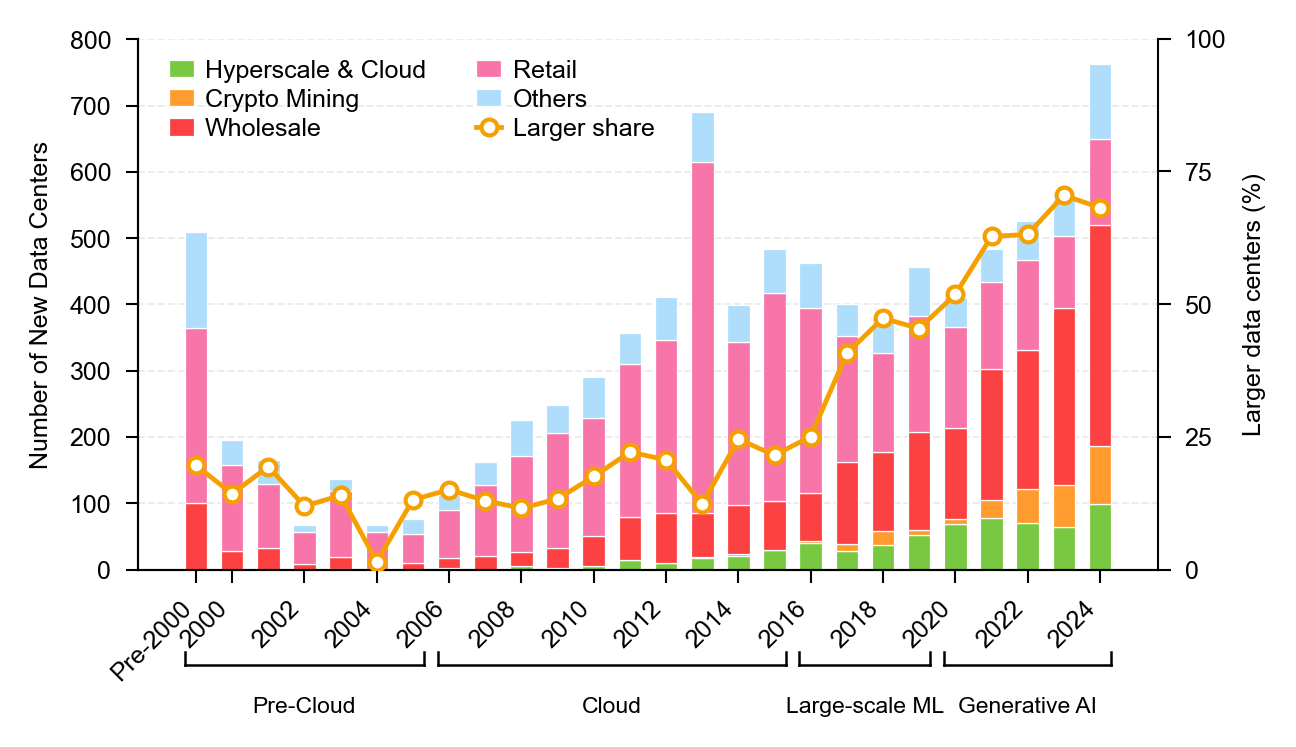

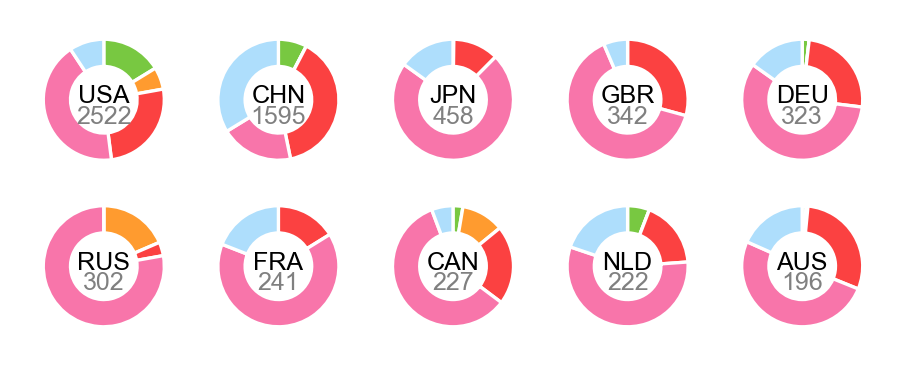


Data Filtering Summary for Fig. 1b
Total data centers after filtering: 9031
Data centers with valid year: 9031
Year range: 1912 - 2024

Top 10 countries (after merging HKG/TWN/MAC into CHN):
Alpha-3 code
USA    2522
CHN    1595
JPN     458
GBR     342
DEU     323
RUS     302
FRA     241
CAN     227
NLD     222
AUS     196
Name: count, dtype: int64

Data center types distribution:
Type_Category
Retail Data Center           4448
Wholesale Data Center        2294
Others                       1361
Hyperscale & Cloud            644
Crypto Mining Data Center     284
Name: count, dtype: int64

Annual larger data-center share (%):
Year_Group
Pre-2000    19.61
2000        14.29
2001        19.39
2002        11.94
2003        13.97
2004         1.49
2005        13.16
2006        15.04
2007        12.96
2008        11.56
2009        13.31
2010        17.53
2011        22.13
2012        20.68
2013        12.32
2014        24.56
2015        21.53
2016        25.05
2017        40.75
2018        47.

In [21]:
# Fig. 1b. Annual new installations by country and data center type from 2000 to 2024.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Nature style settings
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.linewidth': 0.5,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'axes.labelsize': 6,
    'legend.fontsize': 6,
})

# Read data
df_centers = pd.read_excel(os.path.join(RAW, 'SPGlobal_Export.xlsx'), sheet_name='Sheet1')
df_country = pd.read_excel(os.path.join(RAW, 'SPGlobal_Export.xlsx'), sheet_name='country')

# Filter valid samples: non-missing YR_BUILT, LATITUDE, LONGITUDE, and YR_BUILT != 2025
df_centers = df_centers[
    (df_centers['YR_BUILT'].notna()) &
    (df_centers['LATITUDE'].notna()) &
    (df_centers['LONGITUDE'].notna()) &
    (df_centers['YR_BUILT'] != 2025)
].copy()

# Merge country information
df_merged = df_centers.merge(
    df_country[['COUNTRY', 'Alpha-3 code', 'Region']],
    on='COUNTRY',
    how='left'
)

# Filter valid years and create year groups
df_time = df_merged[df_merged['YR_BUILT'].notna()].copy()
df_time['Year_Group'] = df_time['YR_BUILT'].apply(
    lambda x: 'Pre-2000' if x < 2000 else str(int(x))
)

# Data center type colors
type_colors = {
    'Hyperscale & Cloud': '#78C841',
    'Crypto Mining Data Center': '#FF9B2F',
    'Wholesale Data Center': '#FB4141',
    'Retail Data Center': '#F875AA',
    'Others': '#AEDEFC'
}

type_order = [
    'Hyperscale & Cloud',
    'Crypto Mining Data Center',
    'Wholesale Data Center',
    'Retail Data Center',
    'Others'
]

# Categorize types
def categorize_type(type_str):
    if pd.isna(type_str):
        return 'Others'
    type_str = str(type_str).strip()

    if type_str in ['Hyperscale Data Center', 'Cloud Data Center']:
        return 'Hyperscale & Cloud'
    elif type_str in ['Crypto Mining Data Center', 'Wholesale Data Center', 'Retail Data Center']:
        return type_str
    else:
        return 'Others'

df_time['Type_Category'] = df_time['SECONDARY_PPTY_TYPE'].apply(categorize_type)

# Larger data centers for secondary-axis share.
# Crypto is kept as a separate type, not grouped into larger facilities.
larger_categories = ['Hyperscale & Cloud', 'Wholesale Data Center', 'Crypto Mining Data Center']
df_time['Larger_DC'] = df_time['Type_Category'].isin(larger_categories).astype(int)

# ===== Part 1: Stacked bar chart by type + larger share line =====
yearly_type_counts = df_time.groupby(['Year_Group', 'Type_Category']).size().reset_index(name='count')
pivot_yearly = yearly_type_counts.pivot_table(
    index='Year_Group',
    columns='Type_Category',
    values='count',
    fill_value=0
)

# Ensure all types exist
for type_name in type_order:
    if type_name not in pivot_yearly.columns:
        pivot_yearly[type_name] = 0

pivot_yearly = pivot_yearly[type_order]

# Sort years: Pre-2000 first, then 2000-2024
year_labels = ['Pre-2000'] + [str(y) for y in range(2000, 2025)]
pivot_yearly = pivot_yearly.reindex(year_labels, fill_value=0)

# Larger share by year group
yearly_total = pivot_yearly.sum(axis=1)
yearly_larger = pivot_yearly[larger_categories].sum(axis=1)
larger_share = (yearly_larger / yearly_total.replace(0, np.nan)) * 100
larger_share = larger_share.reindex(year_labels)

fig1, ax1 = plt.subplots(figsize=(4.3, 2.7), dpi=300)

x = np.arange(len(pivot_yearly)) * 0.8
width = 0.5
bottom = np.zeros(len(pivot_yearly))

bar_handles = []

for type_name in type_order:
    values = pivot_yearly[type_name].values
    label = type_name.replace(' Data Center', '')
    bars = ax1.bar(
        x, values, width, bottom=bottom,
        label=label,
        color=type_colors[type_name],
        edgecolor='white', linewidth=0.3
    )
    bar_handles.append(bars[0])
    bottom += values

ax1.set_ylabel('Number of New Data Centers')
ax1.set_xlabel('')

# Secondary axis: share of larger data centers
ax2 = ax1.twinx()

line_color = '#F5A000'
line = ax2.plot(
    x,
    larger_share.values,
    color=line_color,
    linewidth=1.15,
    marker='o',
    markersize=3.8,
    markerfacecolor='white',
    markeredgecolor=line_color,
    markeredgewidth=1.0,
    zorder=5,
    label='Larger share'
)

ax2.set_ylabel('Larger data centers (%)', color='black')
ax2.tick_params(axis='y', width=0.5, length=3, colors='black')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_linewidth(0.5)

# Keep right axis clean and comparable
ax2.set_ylim(0, 100)
ax2.set_yticks([0, 25, 50, 75, 100])
ax2.set_yticklabels(['0', '25', '50', '75', '100'])

# X-axis: show Pre-2000 + every other year from 2000
tick_positions = [0] + list(range(1, len(pivot_yearly), 2))
tick_labels = [pivot_yearly.index[i] for i in tick_positions]
ax1.set_xticks([x[i] for i in tick_positions])
ax1.set_xticklabels(tick_labels, rotation=45, ha='right')

ax1.tick_params(axis='both', width=0.5, length=3)

# Combined legend
bar_labels = [t.replace(' Data Center', '') for t in type_order]
handles = bar_handles + [line[0]]
labels = bar_labels + ['Larger share']

ax1.legend(
    handles,
    labels,
    loc='upper left',
    frameon=False,
    bbox_to_anchor=(0.02, 0.98),
    handlelength=1.0,
    handletextpad=0.45,
    labelspacing=0.25,
    borderaxespad=0.0,
    ncol=2
)

ax1.yaxis.grid(True, linestyle='--', alpha=0.25, linewidth=0.45)
ax1.set_axisbelow(True)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(0.5)
ax1.spines['bottom'].set_linewidth(0.5)

# ---------- Era brackets below x-axis ----------
trans = ax1.get_xaxis_transform()

def add_era_bracket(ax, x0, x1, y, label, text_offset=-0.06, lw=0.6):
    ax.plot([x0, x1], [y, y], transform=trans, color='black', lw=lw, clip_on=False)
    ax.plot([x0, x0], [y, y + 0.025], transform=trans, color='black', lw=lw, clip_on=False)
    ax.plot([x1, x1], [y, y + 0.025], transform=trans, color='black', lw=lw, clip_on=False)
    ax.text(
        (x0 + x1) / 2,
        y + text_offset,
        label,
        ha='center',
        va='top',
        transform=trans,
        fontsize=5.5
    )

left_edge = lambda i: x[i] - width / 2
right_edge = lambda i: x[i] + width / 2

add_era_bracket(ax1, left_edge(0), right_edge(6), -0.18, 'Pre-Cloud')
add_era_bracket(ax1, left_edge(7), right_edge(16), -0.18, 'Cloud')
add_era_bracket(ax1, left_edge(17), right_edge(20), -0.18, 'Large-scale ML')
add_era_bracket(ax1, left_edge(21), right_edge(25), -0.18, 'Generative AI')

plt.tight_layout()
plt.subplots_adjust(bottom=0.30)

plt.savefig(
    os.path.join(FIGURES, 'fig1b_datacenter_yearly_stacked_era_clean.tif'),
    dpi=300, bbox_inches='tight', transparent=True,
    pil_kwargs={'compression': 'tiff_lzw'}
)
plt.savefig(
    os.path.join(FIGURES, 'fig1b_datacenter_yearly_stacked_era_clean.pdf'),
    bbox_inches='tight', transparent=True
)

# ===== Part 2: Donut charts (Top 10 countries by count) =====
# Merge Hong Kong, Taiwan, and Macao into China
df_time_merged = df_time.copy()
df_time_merged.loc[df_time_merged['Alpha-3 code'].isin(['HKG', 'TWN', 'MAC']), 'Alpha-3 code'] = 'CHN'

# Automatically get top 10 countries
top10_codes = (
    df_time_merged['Alpha-3 code']
    .value_counts()
    .head(10)
    .index
    .tolist()
)

fig2, axes = plt.subplots(2, 5, figsize=(3, 1.2), dpi=300)
axes = axes.flatten()

for idx, code in enumerate(top10_codes):
    ax = axes[idx]
    country_data = df_time_merged[df_time_merged['Alpha-3 code'] == code]
    type_counts = country_data['Type_Category'].value_counts().reindex(type_order, fill_value=0)
    total = type_counts.sum()

    if total > 0:
        ax.pie(
            type_counts,
            colors=[type_colors[t] for t in type_order],
            startangle=90,
            counterclock=False,
            wedgeprops=dict(width=0.45, edgecolor='white', linewidth=0.8)
        )
    else:
        ax.pie(
            [1],
            colors=['#EEEEEE'],
            wedgeprops=dict(width=0.35, edgecolor='white', linewidth=0.4)
        )

    ax.text(0, 0.05, code, ha='center', va='center', color='black')
    ax.text(0, -0.29, f'{int(total)}', ha='center', va='center', color='gray')
    ax.axis('equal')

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES, 'fig1b_datacenter_type_donuts.tif'),
    dpi=300, bbox_inches='tight', transparent=True,
    pil_kwargs={'compression': 'tiff_lzw'}
)
plt.savefig(
    os.path.join(FIGURES, 'fig1b_datacenter_type_donuts.pdf'),
    bbox_inches='tight', transparent=True
)

plt.show()

# Print filtering summary
print(f"\n{'='*60}")
print("Data Filtering Summary for Fig. 1b")
print(f"{'='*60}")
print(f"Total data centers after filtering: {len(df_centers)}")
print(f"Data centers with valid year: {len(df_time)}")
print(f"Year range: {df_time['YR_BUILT'].min():.0f} - {df_time['YR_BUILT'].max():.0f}")

print("\nTop 10 countries (after merging HKG/TWN/MAC into CHN):")
print(df_time_merged['Alpha-3 code'].value_counts().head(10))

print("\nData center types distribution:")
print(df_time['Type_Category'].value_counts())

print("\nAnnual larger data-center share (%):")
print(larger_share.round(2))

print(f"{'='*60}\n")

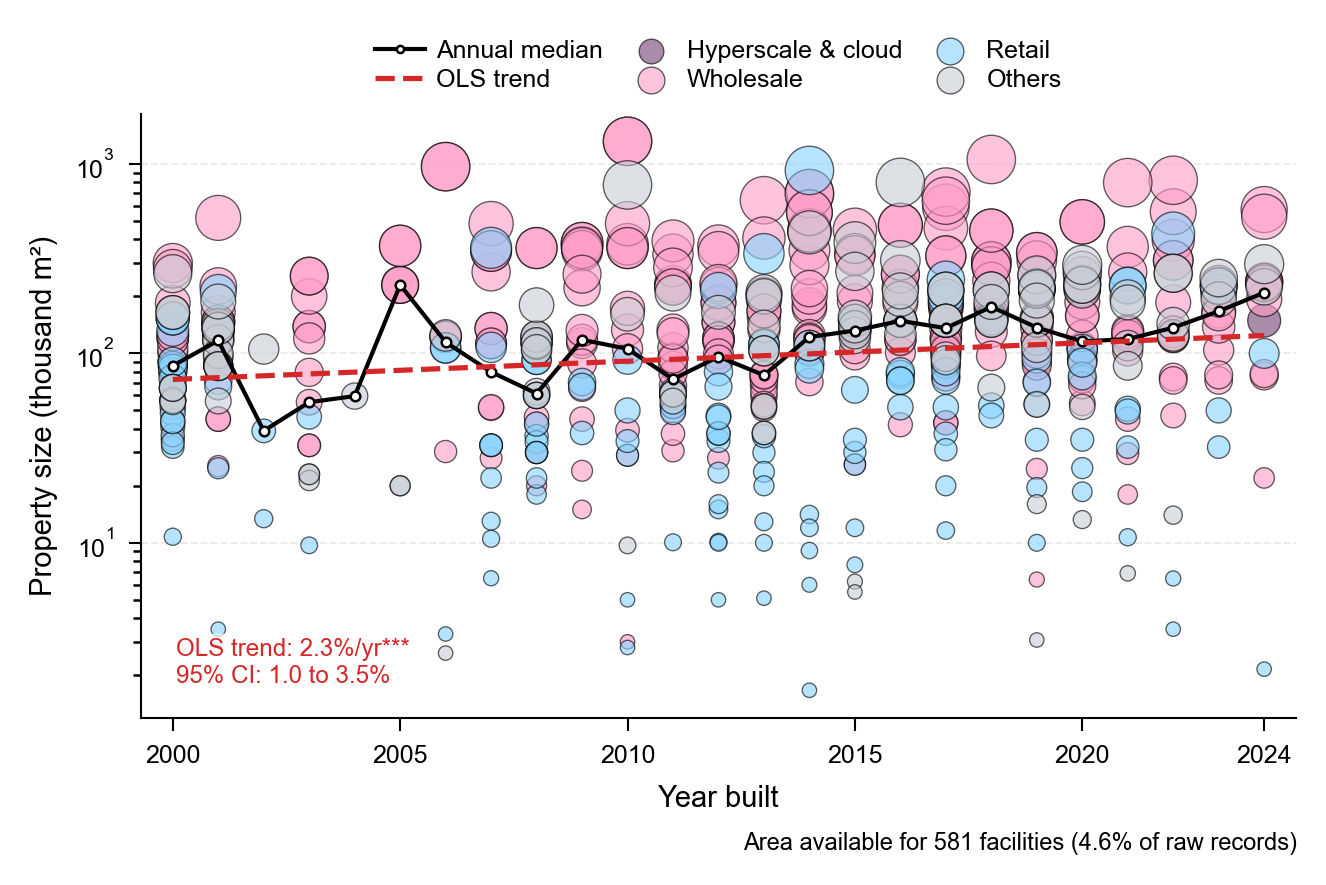


Property-size bubble figure summary
Raw records in SPGlobal_Export.xlsx: 12,629
Records with matched positive PPTY_SIZE_AREA, valid YR_BUILT, 2000-2024: 581
Share of raw records used in this limited-sample figure: 4.60%
PPTY_SIZE_AREA definition: total interior area of the building or buildings
Displayed unit: thousand square meters

OLS trend fitted on all observations with reported property size:
Slope = 0.0097 log10(thousand m²) per year
Implied annual growth = 2.25% per year
95% CI = [1.04%, 3.48%]
P-value = 0.0002639
N = 581, years = 25

Property-size coverage by type:
           Type_Category    n  median_size_sqm  mean_size_sqm   p25_size_sqm  \
3  Wholesale Data Center  305    133878.000000  204363.822979   90000.000000   
2     Retail Data Center  144     43029.229833   70765.502537   20000.000000   
1                 Others  130    135513.000000  146581.192021   63566.031756   
0     Hyperscale & Cloud    2    148790.000000  148790.000000  148685.000000   

    p75_size_sqm 

In [23]:
# Limited-sample evidence on data center physical size over time
# Bubble scatter using PPTY_SIZE_AREA merged by PPTY_KEY.
# PPTY_SIZE_AREA definition: total interior area of the building or buildings, in square meters.
# OLS trend is fitted on all observations with reported property size in log10(size).

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.linewidth': 0.5,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'axes.labelsize': 7,
    'legend.fontsize': 6,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ---------------------------------------------------------------------
# 1. Read and merge data for plotting only
# ---------------------------------------------------------------------

main_path = os.path.join(RAW, 'SPGlobal_Export.xlsx')
size_path = os.path.join(RAW, 'capitaliqpro_datacenter_20260412access.xlsx')

df_main = pd.read_excel(main_path, sheet_name='Sheet1')
df_size = pd.read_excel(size_path, sheet_name='Sheet1')

main_cols = [
    'PPTY_KEY',
    'PPTY_NAME',
    'COUNTRY',
    'SECONDARY_PPTY_TYPE',
    'YR_BUILT',
    'LATITUDE',
    'LONGITUDE'
]
main_cols = [c for c in main_cols if c in df_main.columns]

df_plot = df_main[main_cols].copy()

if 'PPTY_SIZE_AREA' not in df_size.columns:
    raise ValueError("PPTY_SIZE_AREA is not found in capitaliqpro_datacenter_20260412access.xlsx")

df_size_small = df_size[['PPTY_KEY', 'PPTY_SIZE_AREA']].copy()
df_size_small['PPTY_SIZE_AREA'] = pd.to_numeric(
    df_size_small['PPTY_SIZE_AREA'],
    errors='coerce'
)

df_size_small = (
    df_size_small
    .dropna(subset=['PPTY_KEY'])
    .groupby('PPTY_KEY', as_index=False)['PPTY_SIZE_AREA']
    .max()
)

df_plot = df_plot.merge(
    df_size_small,
    on='PPTY_KEY',
    how='left',
    validate='m:1'
)

# ---------------------------------------------------------------------
# 2. Clean and categorize
# ---------------------------------------------------------------------

df_plot = df_plot[
    (df_plot['YR_BUILT'].notna()) &
    (df_plot['YR_BUILT'] != 2025) &
    (df_plot['PPTY_SIZE_AREA'].notna()) &
    (df_plot['PPTY_SIZE_AREA'] > 0)
].copy()

df_plot['YR_BUILT'] = df_plot['YR_BUILT'].astype(int)

df_plot = df_plot[
    (df_plot['YR_BUILT'] >= 2000) &
    (df_plot['YR_BUILT'] <= 2024)
].copy()

df_plot['property_size_sqm'] = df_plot['PPTY_SIZE_AREA']
df_plot['property_size_1000sqm'] = df_plot['property_size_sqm'] / 1000

def categorize_type(type_str):
    if pd.isna(type_str):
        return 'Others'
    type_str = str(type_str).strip()

    if type_str in ['Hyperscale Data Center', 'Cloud Data Center']:
        return 'Hyperscale & Cloud'
    elif type_str in ['Crypto Mining Data Center', 'Wholesale Data Center', 'Retail Data Center']:
        return type_str
    else:
        return 'Others'

df_plot['Type_Category'] = df_plot['SECONDARY_PPTY_TYPE'].apply(categorize_type)

type_order = [
    'Hyperscale & Cloud',
    'Wholesale Data Center',
    'Retail Data Center',
    'Crypto Mining Data Center',
    'Others'
]

type_labels = {
    'Hyperscale & Cloud': 'Hyperscale & cloud',
    'Wholesale Data Center': 'Wholesale',
    'Retail Data Center': 'Retail',
    'Crypto Mining Data Center': 'Crypto mining',
    'Others': 'Others'
}

type_colors = {
    'Hyperscale & Cloud': '#744577',
    'Wholesale Data Center': '#FE9EC7',
    'Retail Data Center': '#89D4FF',
    'Crypto Mining Data Center': '#F9F6C4',
    'Others': '#C9CED6'
}

# ---------------------------------------------------------------------
# 3. Bubble scaling and annual median
# ---------------------------------------------------------------------

area_plot = df_plot['property_size_1000sqm'].astype(float)

area_for_size = area_plot.clip(
    lower=area_plot.quantile(0.02),
    upper=area_plot.quantile(0.98)
)

df_plot['bubble_size'] = np.interp(
    np.sqrt(area_for_size),
    (np.sqrt(area_for_size).min(), np.sqrt(area_for_size).max()),
    (12, 135)
)

annual_stats = (
    df_plot
    .groupby('YR_BUILT')
    .agg(
        median_size_1000sqm=('property_size_1000sqm', 'median'),
        n=('property_size_1000sqm', 'size')
    )
    .reset_index()
)

annual_stats_plot = annual_stats.copy()

# ---------------------------------------------------------------------
# 4. OLS trend on log10(size), clustered by year
# ---------------------------------------------------------------------

trend_df = df_plot[
    (df_plot['property_size_1000sqm'].notna()) &
    (df_plot['property_size_1000sqm'] > 0) &
    (df_plot['YR_BUILT'].notna())
].copy()

trend_df['year_c'] = trend_df['YR_BUILT'] - trend_df['YR_BUILT'].min()
trend_df['log_size'] = np.log10(trend_df['property_size_1000sqm'])

X = sm.add_constant(trend_df['year_c'])
y = trend_df['log_size']

trend_model = sm.OLS(y, X).fit(
    cov_type='cluster',
    cov_kwds={'groups': trend_df['YR_BUILT']}
)

slope = trend_model.params['year_c']
pval = trend_model.pvalues['year_c']
ci_low, ci_high = trend_model.conf_int().loc['year_c']

annual_growth = (10 ** slope - 1) * 100
annual_growth_low = (10 ** ci_low - 1) * 100
annual_growth_high = (10 ** ci_high - 1) * 100

sig = (
    '***' if pval < 0.001 else
    '**' if pval < 0.01 else
    '*' if pval < 0.05 else
    '+' if pval < 0.10 else
    ''
)

trend_label = (
    f"OLS trend: {annual_growth:.1f}%/yr{sig}\n"
    f"95% CI: {annual_growth_low:.1f} to {annual_growth_high:.1f}%"
)

x_trend = np.arange(trend_df['YR_BUILT'].min(), trend_df['YR_BUILT'].max() + 1)
x_trend_c = x_trend - trend_df['YR_BUILT'].min()
y_trend = 10 ** (trend_model.params['const'] + slope * x_trend_c)

# ---------------------------------------------------------------------
# 5. Plot
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(4.4, 3.05), dpi=300)

for t in type_order:
    dat = df_plot[df_plot['Type_Category'] == t]
    if dat.empty:
        continue

    ax.scatter(
        dat['YR_BUILT'],
        dat['property_size_1000sqm'],
        s=dat['bubble_size'],
        c=type_colors[t],
        edgecolors='black',
        linewidths=0.32,
        alpha=0.62,
        label=type_labels[t],
        zorder=3
    )

if len(annual_stats_plot) > 0:
    ax.plot(
        annual_stats_plot['YR_BUILT'],
        annual_stats_plot['median_size_1000sqm'],
        color='black',
        linewidth=1.0,
        marker='o',
        markersize=2.3,
        markerfacecolor='white',
        markeredgecolor='black',
        markeredgewidth=0.6,
        zorder=5,
        label='Annual median'
    )

ax.plot(
    x_trend,
    y_trend,
    color='#D62728',
    linewidth=1.25,
    linestyle='--',
    zorder=6,
    label='OLS trend'
)

ax.set_yscale('log')

ax.set_xlabel('Year built')
ax.set_ylabel('Property size (thousand m²)')

ax.set_xlim(1999.3, 2024.7)
ax.set_xticks([2000, 2005, 2010, 2015, 2020, 2024])
ax.set_xticklabels(['2000', '2005', '2010', '2015', '2020', '2024'])

ax.tick_params(axis='both', width=0.5, length=3)

ax.yaxis.grid(True, linestyle='--', alpha=0.25, linewidth=0.45)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

ax.text(
    0.03, 0.05,
    trend_label,
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=5.8,
    color='#D62728',
    bbox=dict(
        facecolor='white',
        edgecolor='none',
        alpha=0.72,
        boxstyle='round,pad=0.18'
    )
)

handles, labels = ax.get_legend_handles_labels()

priority_labels = ['Annual median', 'OLS trend']
new_handles, new_labels = [], []

for lab in priority_labels:
    if lab in labels:
        idx = labels.index(lab)
        new_handles.append(handles[idx])
        new_labels.append(labels[idx])

for h, lab in zip(handles, labels):
    if lab not in priority_labels:
        new_handles.append(h)
        new_labels.append(lab)

ax.legend(
    new_handles,
    new_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    frameon=False,
    handletextpad=0.45,
    columnspacing=0.9,
    labelspacing=0.25,
    borderaxespad=0.0,
    markerscale=0.75,
    ncol=3
)

coverage_text = (
    f"Area available for {len(df_plot):,} facilities "
    f"({len(df_plot) / len(df_main):.1%} of raw records)"
)

fig.text(
    0.98, 0.01,
    coverage_text,
    ha='right',
    va='bottom',
    fontsize=5.7,
    color='black'
)

plt.tight_layout()
plt.subplots_adjust(top=0.82, bottom=0.16)

plt.savefig(
    os.path.join(FIGURES, 'fig1b_datacenter_property_size_bubble_limited_sample_log_trend_sig.tif'),
    dpi=300,
    bbox_inches='tight',
    transparent=True,
    pil_kwargs={'compression': 'tiff_lzw'}
)

plt.savefig(
    os.path.join(FIGURES, 'fig1b_datacenter_property_size_bubble_limited_sample_log_trend_sig.pdf'),
    bbox_inches='tight',
    transparent=True
)

plt.show()

# ---------------------------------------------------------------------
# 6. Export diagnostics
# ---------------------------------------------------------------------

coverage_by_type = (
    df_plot
    .groupby('Type_Category')
    .agg(
        n=('property_size_sqm', 'size'),
        median_size_sqm=('property_size_sqm', 'median'),
        mean_size_sqm=('property_size_sqm', 'mean'),
        p25_size_sqm=('property_size_sqm', lambda x: x.quantile(0.25)),
        p75_size_sqm=('property_size_sqm', lambda x: x.quantile(0.75))
    )
    .reset_index()
    .sort_values('n', ascending=False)
)

coverage_by_year = annual_stats.copy()

coverage_by_type.to_csv(
    os.path.join(TABLES, 'fig1b_property_size_limited_sample_by_type.csv'),
    index=False
)

coverage_by_year.to_csv(
    os.path.join(TABLES, 'fig1b_property_size_limited_sample_by_year.csv'),
    index=False
)

print(f"\n{'='*60}")
print("Property-size bubble figure summary")
print(f"{'='*60}")
print(f"Raw records in SPGlobal_Export.xlsx: {len(df_main):,}")
print(f"Records with matched positive PPTY_SIZE_AREA, valid YR_BUILT, 2000-2024: {len(df_plot):,}")
print(f"Share of raw records used in this limited-sample figure: {len(df_plot) / len(df_main):.2%}")
print("PPTY_SIZE_AREA definition: total interior area of the building or buildings")
print("Displayed unit: thousand square meters")
print("\nOLS trend fitted on all observations with reported property size:")
print(f"Slope = {slope:.4f} log10(thousand m²) per year")
print(f"Implied annual growth = {annual_growth:.2f}% per year")
print(f"95% CI = [{annual_growth_low:.2f}%, {annual_growth_high:.2f}%]")
print(f"P-value = {pval:.4g}")
print(f"N = {len(trend_df):,}, years = {trend_df['YR_BUILT'].nunique()}")

print("\nProperty-size coverage by type:")
print(coverage_by_type)

print("\nAnnual median property-size sample size:")
print(coverage_by_year.tail(10))

print(f"{'='*60}\n")

In [ ]:
# Figure 2. Proximity of data centers to power generation infrastructure. 
# a, Distribution of distance between data centers (by establishment phase: <2006, 2006-2015, 2016-2019, 2020-2024) and their nearest power plants (coal, oil & gas, solar & wind) for the top 10 data center markets. 
# b, Energy source composition of generation capacity for these nearest power plants by country and phase.

In [6]:
# a, calculation section

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# ==================== Settings ====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2

# ==================== Load data ====================
oilgas_df = pd.read_excel(os.path.join(RAW, "Global-Oil-and-Gas-Plant-Tracker-GOGPT-January-2025.xlsx"), sheet_name="all")
oilgas_country = pd.read_excel(os.path.join(RAW, "Global-Oil-and-Gas-Plant-Tracker-GOGPT-January-2025.xlsx"), sheet_name="country")

coal_df = pd.read_excel(os.path.join(RAW, "Global-Coal-Plant-Tracker-January-2025.xlsx"), sheet_name="Units")
coal_country = pd.read_excel(os.path.join(RAW, "Global-Coal-Plant-Tracker-January-2025.xlsx"), sheet_name="country")

solar_df = pd.read_excel(os.path.join(RAW, "Global-Solar-Power-Tracker-February-2025.xlsx"), sheet_name="all")
solar_country = pd.read_excel(os.path.join(RAW, "Global-Solar-Power-Tracker-February-2025.xlsx"), sheet_name="country")

wind_df = pd.read_excel(os.path.join(RAW, "Global-Wind-Power-Tracker-February-2025.xlsx"), sheet_name="Data")
wind_country = pd.read_excel(os.path.join(RAW, "Global-Wind-Power-Tracker-February-2025.xlsx"), sheet_name="country")

ai_df = pd.read_excel(os.path.join(RAW, "sp_global_ai_center.xlsx"), sheet_name="Sheet1")
ai_country = pd.read_excel(os.path.join(RAW, "sp_global_ai_center.xlsx"), sheet_name="country")


# ==================== Process plant data ====================
def process_plant_data(plant_df, country_df, plant_type):
    plant_clean = plant_df[
        (plant_df['Status'].isin(['operating', 'retired'])) &
        (plant_df['Latitude'].notna()) &
        (plant_df['Longitude'].notna())
    ].copy()
    
    plant_clean['Latitude'] = pd.to_numeric(plant_clean['Latitude'], errors='coerce')
    plant_clean['Longitude'] = pd.to_numeric(plant_clean['Longitude'], errors='coerce')
    plant_clean['Start year'] = pd.to_numeric(plant_clean['Start year'], errors='coerce')
    plant_clean['Retired year'] = pd.to_numeric(plant_clean['Retired year'], errors='coerce')
    plant_clean['Capacity (MW)'] = pd.to_numeric(plant_clean['Capacity (MW)'], errors='coerce')
    
    plant_clean = plant_clean.dropna(subset=['Latitude', 'Longitude'])
    
    plant_clean = plant_clean.merge(
        country_df[['Country/Area', 'Alpha-2 code', 'Alpha-3 code', 'Numeric', 'Region']],
        on='Country/Area',
        how='left'
    )
    
    plant_clean['plant_type'] = plant_type
    return plant_clean

oilgas_processed = process_plant_data(oilgas_df, oilgas_country, 'Oil & Gas')
coal_processed = process_plant_data(coal_df, coal_country, 'Coal')
solar_processed = process_plant_data(solar_df, solar_country, 'Solar')
wind_processed = process_plant_data(wind_df, wind_country, 'Wind')

all_plants = pd.concat([oilgas_processed, coal_processed, solar_processed, wind_processed], ignore_index=True)

# ==================== Process AI data centers ====================
ai_clean = ai_df[
    (ai_df['LATITUDE'].notna()) &
    (ai_df['LONGITUDE'].notna())
].copy()

ai_clean['LATITUDE'] = pd.to_numeric(ai_clean['LATITUDE'], errors='coerce')
ai_clean['LONGITUDE'] = pd.to_numeric(ai_clean['LONGITUDE'], errors='coerce')
ai_clean['YR_BUILT'] = pd.to_numeric(ai_clean['YR_BUILT'], errors='coerce')

ai_clean = ai_clean.dropna(subset=['LATITUDE', 'LONGITUDE'])

ai_clean = ai_clean.merge(
    ai_country[['COUNTRY', 'Alpha-2 code', 'Alpha-3 code', 'Numeric', 'Region']],
    on='COUNTRY',
    how='left'
)

# Merge Hong Kong, Taiwan, and Macau into China
ai_clean.loc[ai_clean['Alpha-3 code'].isin(['HKG', 'TWN', 'MAC']), 'Alpha-3 code'] = 'CHN'

# ==================== Check if plant is operating ====================
def is_operating_at_time(row, ai_year):
    start_year = row['Start year']
    status = row['Status']
    retired_year = row['Retired year']
    
    if pd.isna(start_year) or start_year > ai_year:
        return False
    if status == 'operating':
        return True
    if status == 'retired':
        if retired_year >= ai_year:
            return True
    return False

# ==================== Optimized distance calculation ====================
def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    Vectorized Haversine formula to calculate distances in km
    """
    R = 6371
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

# ==================== Calculate distances ====================
results = []
countries = ai_clean['Alpha-3 code'].dropna().unique()

for country in countries:
    ai_country_data = ai_clean[ai_clean['Alpha-3 code'] == country]
    
    for idx, ai_row in ai_country_data.iterrows():
        ai_year = ai_row['YR_BUILT']
        
        if pd.isna(ai_year):
            continue
        
        country_plants = all_plants[all_plants['Alpha-3 code'] == country].copy()
        country_plants['is_operating'] = country_plants.apply(
            lambda x: is_operating_at_time(x, ai_year), axis=1
        )
        operating_plants = country_plants[country_plants['is_operating']]
        
        if len(operating_plants) == 0:
            continue
        
        distances_km = haversine_vectorized(
            ai_row['LATITUDE'],
            ai_row['LONGITUDE'],
            operating_plants['Latitude'].values,
            operating_plants['Longitude'].values
        )
        
        min_distance = distances_km.min()
        
        results.append({
            'country': country,
            'ai_year': ai_year,
            'nearest_distance_km': min_distance
        })

results_df = pd.DataFrame(results)

# ==================== Classify by time periods ====================
def classify_year(year):
    if pd.isna(year):
        return None
    if year < 2006:
        return "Phase I: <2006"
    elif 2006 <= year <= 2015:
        return "Phase II: 2006-2015"
    elif 2016 <= year <= 2019:
        return "Phase III: 2016-2019"
    elif 2020 <= year <= 2024:
        return "Phase IV: 2020-2024"
    return None

results_df['year_group'] = results_df['ai_year'].apply(classify_year)
results_df = results_df.dropna(subset=['year_group'])

# ==================== Save intermediate data ====================

results_df['year_group'] = pd.Categorical(
    results_df['year_group'],
    categories=["Phase I: <2006", "Phase II: 2006-2015", "Phase III: 2016-2019", "Phase IV: 2020-2024"],
    ordered=True
)

results_df.to_csv(os.path.join(TEMP, 'intermediate_data_top10.csv'), index=False)



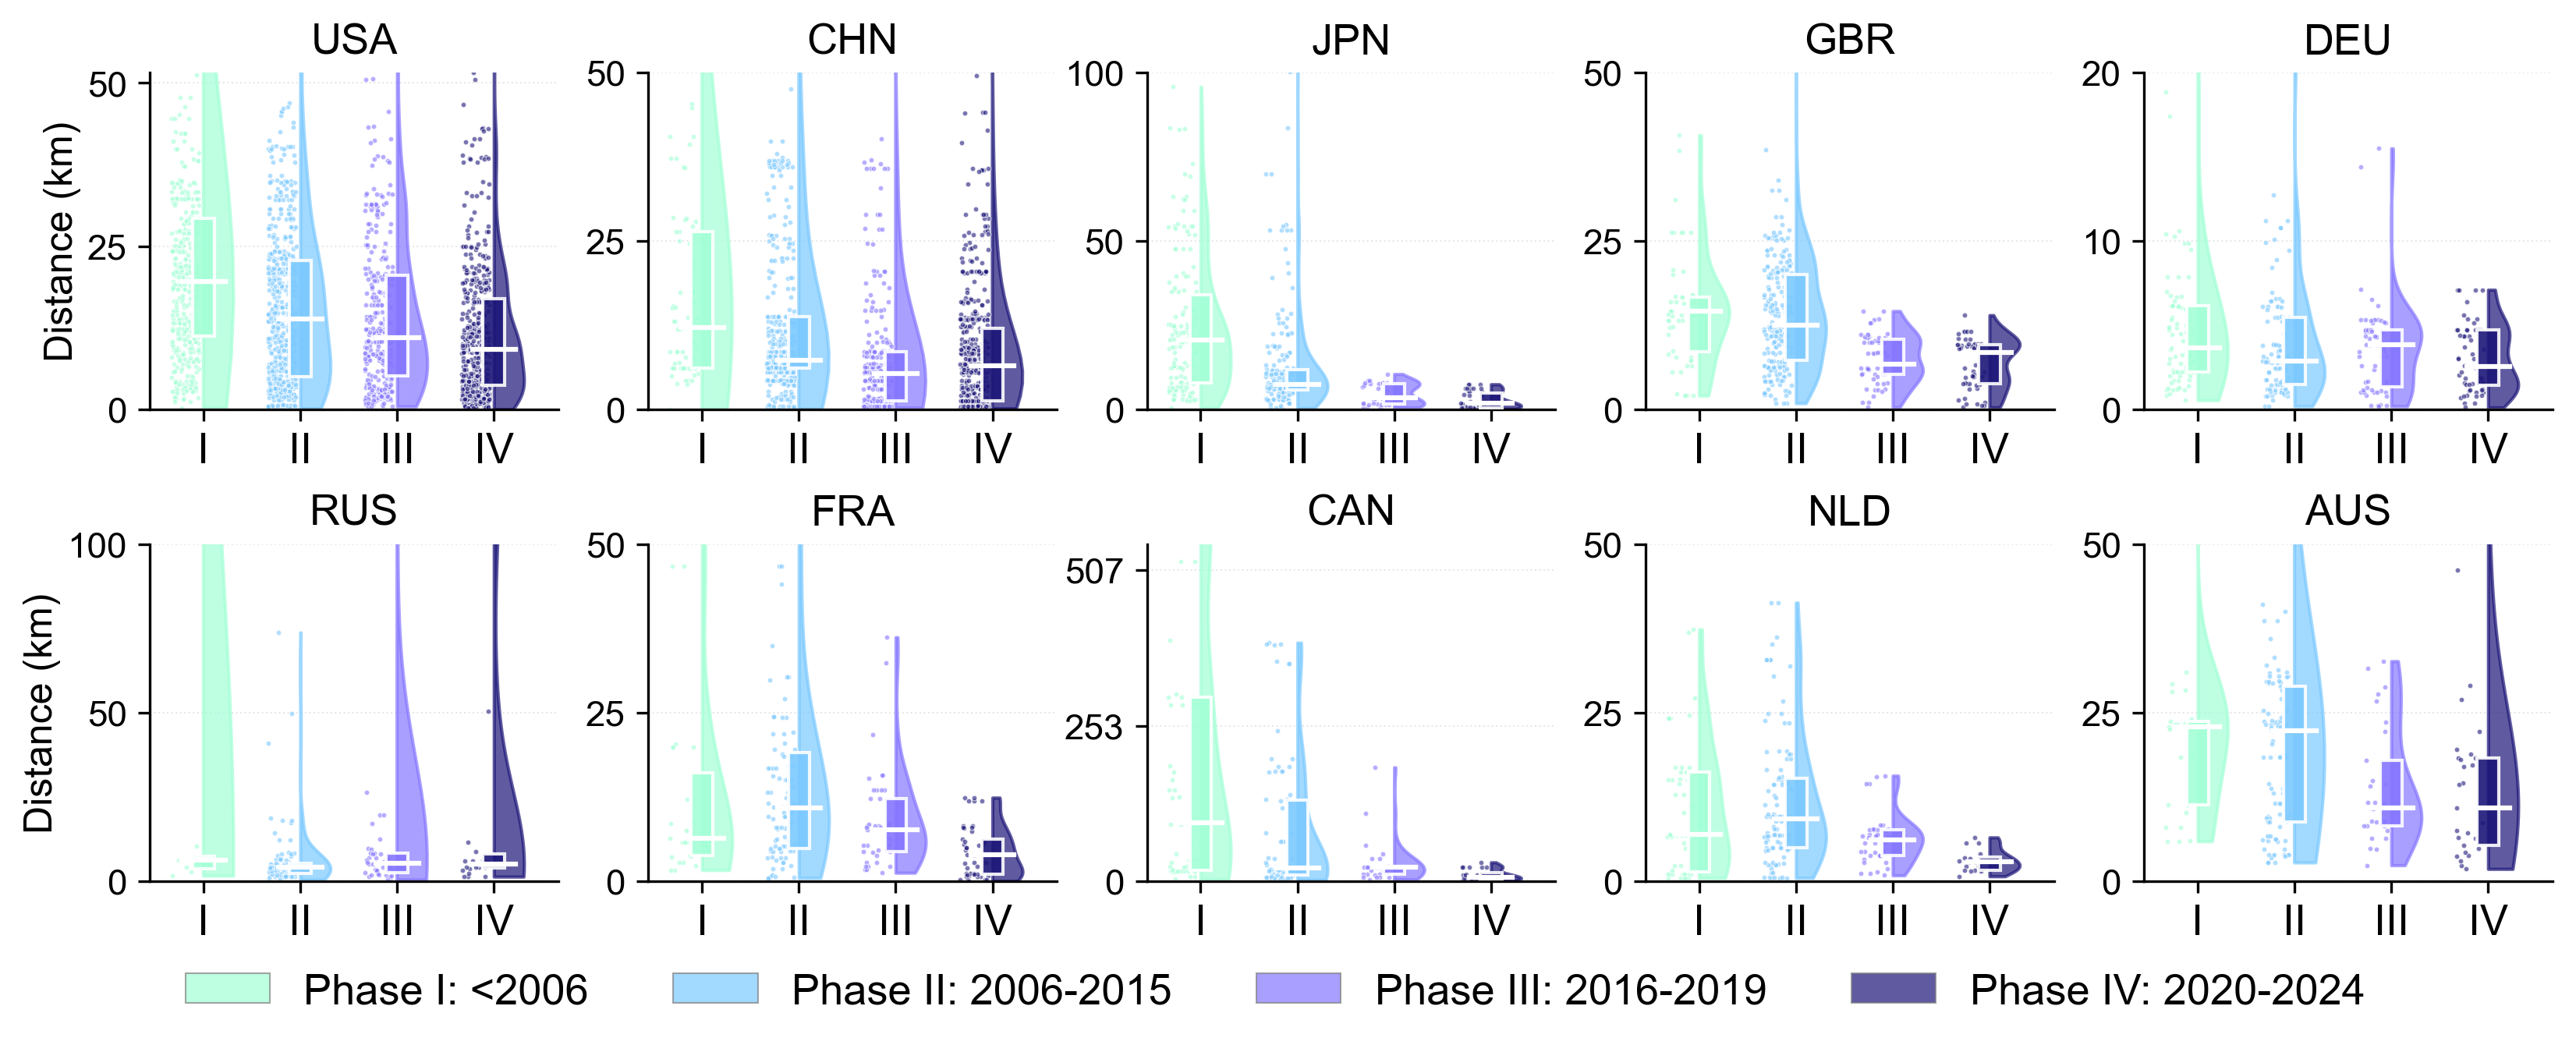

In [16]:
# a, plot section 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# ==================== Nature style settings ====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 0.8

# ==================== Load data ====================
df_plot = pd.read_csv(os.path.join(TEMP, 'intermediate_data_top10.csv'))

df_plot['year_group'] = pd.Categorical(
    df_plot['year_group'],
    categories=["Phase I: <2006", "Phase II: 2006-2015", "Phase III: 2016-2019", "Phase IV: 2020-2024"], 
    ordered=True
)

top10_countries = ['USA', 'CHN', 'JPN', 'GBR', 'DEU', 'RUS', 'FRA', 'CAN', 'NLD', 'AUS']

df_plot = df_plot[df_plot['country'].isin(top10_countries)].copy()
df_plot['country'] = pd.Categorical(
    df_plot['country'],
    categories=top10_countries,
    ordered=True
)


# ==================== Color scheme ====================
period_colors = {
    "Phase I: <2006": "#A3FFD6",  
    "Phase II: 2006-2015": "#7BC9FF", 
    "Phase III: 2016-2019": "#8576FF",
    "Phase IV: 2020-2024": "#1C1678"
}

# ==================== Create figure ====================
fig = plt.figure(figsize=(13, 4.8), dpi=300)

from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 5, figure=fig, 
              left=0.06, right=0.85, 
              top=0.86, bottom=0.14,
              hspace=0.40, wspace=0.22)

for idx, country in enumerate(top10_countries):
    row = idx // 5
    col = idx % 5
    ax = fig.add_subplot(gs[row, col])
    
    country_data = df_plot[df_plot['country'] == country]
    
    if len(country_data) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                fontsize=11, color='gray', transform=ax.transAxes)
        ax.set_xlim(0, 2.5)
        ax.set_title(country, fontsize=12, pad=5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        continue
    
    positions = []
    data_list = []
    colors_list = []
    
    position_mapping = {0: 0, 1: 0.45, 2: 0.9, 3: 1.35}
    
    
    for i, period in enumerate(["Phase I: <2006", "Phase II: 2006-2015", "Phase III: 2016-2019", "Phase IV: 2020-2024"]): 
        period_data = country_data[country_data['year_group'] == period]['nearest_distance_km']
        if len(period_data) >= 1:
            positions.append(position_mapping[i])
            data_list.append(period_data.values)
            colors_list.append(period_colors[period])

    
    if len(data_list) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                fontsize=11, color='gray', transform=ax.transAxes)
        ax.set_xlim(0, 2.5)
        ax.set_title(country, fontsize=12, pad=5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        continue
    
    # Violin plot
    parts = ax.violinplot(data_list, positions=positions, widths=0.28,
                          showmeans=False, showmedians=False, showextrema=False)
    
    for pc, color in zip(parts['bodies'], colors_list):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
        pc.set_edgecolor(color)
        pc.set_linewidth(1.0)
        
        vertices = pc.get_paths()[0].vertices
        center_x = positions[colors_list.index(color)]
        vertices[:, 0] = np.clip(vertices[:, 0], center_x, center_x + 0.28)
    
    # Box plot
    for i, (pos, data) in enumerate(zip(positions, data_list)):
        q1, median, q3 = np.percentile(data, [25, 50, 75])
        
        ax.plot([pos-0.10, pos+0.10], [median, median], 
                color='white', linewidth=1.5, zorder=4)
        
        ax.add_patch(Rectangle((pos - 0.05, q1), 0.10, q3-q1,
                               facecolor=colors_list[i], edgecolor='white',
                               alpha=0.9, linewidth=1.0, zorder=3))
    
    # Scatter points
    for i, (pos, data) in enumerate(zip(positions, data_list)):
        jitter = np.random.uniform(-0.15, -0.02, len(data))
        ax.scatter(pos + jitter, data, alpha=0.6, s=2.5,
                  color=colors_list[i], edgecolors='white',
                  linewidths=0.3, zorder=2)
    
    ax.set_xlim(-0.25, 1.65)
    
    all_data = np.concatenate(data_list)
    y_max = np.percentile(all_data, 95)
    y_max = max(y_max, 10)
    ax.set_ylim(0, y_max * 1.08)
    
    ax.set_xticks([0, 0.45, 0.9, 1.35])
    ax.set_xticklabels(['I', 'II', 'III', 'IV'], fontsize=13, ha='center')
    
    if y_max <= 20:
        y_ticks = [0, 10, 20]
    elif y_max <= 50:
        y_ticks = [0, 25, 50]
    elif y_max <= 100:
        y_ticks = [0, 50, 100]
    else:
        y_ticks = [0, int(y_max/2), int(y_max)]
    
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{int(y)}' for y in y_ticks], fontsize=11)
    
    ax.set_title(country, fontsize=13, pad=6)
    ax.grid(axis='y', linestyle=':', alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    
    if col == 0:
        ax.set_ylabel('Distance (km)', fontsize=12, labelpad=2)

# ==================== Legend ====================
legend_elements = [
    Rectangle((0, 0), 1, 1, fc=period_colors["Phase I: <2006"], alpha=0.7,  
              edgecolor='gray', linewidth=0.5, label='Phase I: <2006'),  
    Rectangle((0, 0), 1, 1, fc=period_colors["Phase II: 2006-2015"], alpha=0.7, 
              edgecolor='gray', linewidth=0.5, label='Phase II: 2006-2015'), 
    Rectangle((0, 0), 1, 1, fc=period_colors["Phase III: 2016-2019"], alpha=0.7, 
              edgecolor='gray', linewidth=0.5, label='Phase III: 2016-2019'),
    Rectangle((0, 0), 1, 1, fc=period_colors["Phase IV: 2020-2024"], alpha=0.7, 
              edgecolor='gray', linewidth=0.5, label='Phase IV: 2020-2024')
]


fig.legend(handles=legend_elements, 
          loc='lower center',
          bbox_to_anchor=(0.43, -0.01),
          ncol=4,
          frameon=False, 
          fontsize=13)


plt.savefig(os.path.join(FIGURES, 'fig2a.pdf'), dpi=300, bbox_inches='tight')
plt.show()


In [8]:
# b, calculation section

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# ==================== Settings ====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7
plt.rcParams['axes.linewidth'] = 0.5

# ==================== Load data ====================
oilgas_df = pd.read_excel(os.path.join(RAW, "Global-Oil-and-Gas-Plant-Tracker-GOGPT-January-2025.xlsx"), sheet_name="all")
oilgas_country = pd.read_excel(os.path.join(RAW, "Global-Oil-and-Gas-Plant-Tracker-GOGPT-January-2025.xlsx"), sheet_name="country")

coal_df = pd.read_excel(os.path.join(RAW, "Global-Coal-Plant-Tracker-January-2025.xlsx"), sheet_name="Units")
coal_country = pd.read_excel(os.path.join(RAW, "Global-Coal-Plant-Tracker-January-2025.xlsx"), sheet_name="country")

solar_df = pd.read_excel(os.path.join(RAW, "Global-Solar-Power-Tracker-February-2025.xlsx"), sheet_name="all")
solar_country = pd.read_excel(os.path.join(RAW, "Global-Solar-Power-Tracker-February-2025.xlsx"), sheet_name="country")

wind_df = pd.read_excel(os.path.join(RAW, "Global-Wind-Power-Tracker-February-2025.xlsx"), sheet_name="Data")
wind_country = pd.read_excel(os.path.join(RAW, "Global-Wind-Power-Tracker-February-2025.xlsx"), sheet_name="country")

ai_df = pd.read_excel(os.path.join(RAW, "SPGlobal_Export.xlsx"), sheet_name="Sheet1")
ai_country = pd.read_excel(os.path.join(RAW, "SPGlobal_Export.xlsx"), sheet_name="country")


# ==================== Process plant data ====================
def process_plant_data(plant_df, country_df, plant_type):
    plant_clean = plant_df[
        (plant_df['Status'].isin(['operating', 'retired'])) &
        (plant_df['Latitude'].notna()) &
        (plant_df['Longitude'].notna())
    ].copy()
    
    plant_clean['Latitude'] = pd.to_numeric(plant_clean['Latitude'], errors='coerce')
    plant_clean['Longitude'] = pd.to_numeric(plant_clean['Longitude'], errors='coerce')
    plant_clean['Start year'] = pd.to_numeric(plant_clean['Start year'], errors='coerce')
    plant_clean['Retired year'] = pd.to_numeric(plant_clean['Retired year'], errors='coerce')
    plant_clean['Capacity (MW)'] = pd.to_numeric(plant_clean['Capacity (MW)'], errors='coerce')
    
    plant_clean = plant_clean.dropna(subset=['Latitude', 'Longitude'])
    
    plant_clean = plant_clean.merge(
        country_df[['Country/Area', 'Alpha-2 code', 'Alpha-3 code', 'Numeric', 'Region']],
        on='Country/Area',
        how='left'
    )
    
    plant_clean['plant_type'] = plant_type
    return plant_clean

oilgas_processed = process_plant_data(oilgas_df, oilgas_country, 'Oil & Gas')
coal_processed = process_plant_data(coal_df, coal_country, 'Coal')
solar_processed = process_plant_data(solar_df, solar_country, 'Solar')
wind_processed = process_plant_data(wind_df, wind_country, 'Wind')

all_plants = pd.concat([oilgas_processed, coal_processed, solar_processed, wind_processed], ignore_index=True)

# ==================== Process AI data centers ====================
ai_clean = ai_df[
    (ai_df['LATITUDE'].notna()) &
    (ai_df['LONGITUDE'].notna())
].copy()

ai_clean['LATITUDE'] = pd.to_numeric(ai_clean['LATITUDE'], errors='coerce')
ai_clean['LONGITUDE'] = pd.to_numeric(ai_clean['LONGITUDE'], errors='coerce')
ai_clean['YR_BUILT'] = pd.to_numeric(ai_clean['YR_BUILT'], errors='coerce')

ai_clean = ai_clean.dropna(subset=['LATITUDE', 'LONGITUDE'])

ai_clean = ai_clean.merge(
    ai_country[['COUNTRY', 'Alpha-2 code', 'Alpha-3 code', 'Numeric', 'Region']],
    on='COUNTRY',
    how='left'
)

# Merge Hong Kong, Taiwan, and Macau into China
ai_clean.loc[ai_clean['Alpha-3 code'].isin(['HKG', 'TWN', 'MAC']), 'Alpha-3 code'] = 'CHN'

# ==================== Check if plant is operating ====================
def is_operating_at_time(row, ai_year):
    start_year = row['Start year']
    status = row['Status']
    retired_year = row['Retired year']
    
    if pd.isna(start_year) or start_year > ai_year:
        return False
    if status == 'operating':
        return True
    if status == 'retired':
        if retired_year >= ai_year:
            return True
    return False

# ==================== Optimized distance calculation ====================
def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def find_nearest_plant(ai_coords, operating_plants):
    """
    Find the nearest power plant to the AI data center.
    Returns: plant_type, capacity, distance
    """
    if len(operating_plants) == 0:
        return None, 0, np.nan
    
    distances = haversine_vectorized(
        ai_coords[0], 
        ai_coords[1],
        operating_plants['Latitude'].values,
        operating_plants['Longitude'].values
    )
    
    # Find the index of the nearest plant
    nearest_idx = np.argmin(distances)
    nearest_plant = operating_plants.iloc[nearest_idx]
    
    return (nearest_plant['plant_type'], 
            nearest_plant['Capacity (MW)'], 
            distances[nearest_idx])

# ==================== Calculate nearest plant for each DC ====================
results = []
countries = ai_clean['Alpha-3 code'].dropna().unique()

for country in countries:
    ai_country_data = ai_clean[ai_clean['Alpha-3 code'] == country]
    country_plants = all_plants[all_plants['Alpha-3 code'] == country].copy()
    
    if len(country_plants) == 0:
        continue
    
    for idx, ai_row in ai_country_data.iterrows():
        ai_year = ai_row['YR_BUILT']
        
        if pd.isna(ai_year):
            continue
        
        country_plants['is_operating'] = country_plants.apply(
            lambda x: is_operating_at_time(x, ai_year), axis=1
        )
        operating_plants = country_plants[country_plants['is_operating']]
        
        if len(operating_plants) == 0:
            continue
        
        ai_coords = (ai_row['LATITUDE'], ai_row['LONGITUDE'])
        plant_type, capacity, distance = find_nearest_plant(ai_coords, operating_plants)
        
        # Initialize all capacities to 0
        coal_cap = 0
        oilgas_cap = 0
        solar_wind_cap = 0
        
        # Assign capacity based on plant type
        if plant_type == 'Coal':
            coal_cap = capacity
        elif plant_type == 'Oil & Gas':
            oilgas_cap = capacity
        elif plant_type in ['Solar', 'Wind']:
            solar_wind_cap = capacity
        
        results.append({
            'country': country,
            'ai_year': ai_year,
            'coal_capacity_mw': coal_cap,
            'oilgas_capacity_mw': oilgas_cap,
            'solar_wind_capacity_mw': solar_wind_cap
        })

results_df = pd.DataFrame(results)

# ==================== Classify by time periods ====================
def classify_year(year):
    if pd.isna(year):
        return None
    if year < 2006:
        return "<2006"
    elif 2006 <= year <= 2015:
        return "2006-2015"
    elif 2016 <= year <= 2019:
        return "2016-2019"
    elif 2020 <= year <= 2024:
        return "2020-2024"
    return None

results_df['year_group'] = results_df['ai_year'].apply(classify_year)
results_df = results_df.dropna(subset=['year_group'])

# ==================== Calculate total capacity by country and period ====================
country_stats = results_df.groupby(['country', 'year_group']).agg({
    'coal_capacity_mw': 'sum',
    'oilgas_capacity_mw': 'sum',
    'solar_wind_capacity_mw': 'sum',
    'ai_year': 'count'
}).reset_index()

country_stats.columns = ['country', 'year_group', 'coal_cap_avg', 'oilgas_cap_avg', 
                         'solar_wind_cap_avg', 'total']


plot_data = country_stats.copy()

# Calculate percentages
plot_data['total_capacity'] = (plot_data['coal_cap_avg'] + 
                                plot_data['oilgas_cap_avg'] + 
                                plot_data['solar_wind_cap_avg'])


plot_data['coal_pct'] = (plot_data['coal_cap_avg'] / plot_data['total_capacity']) * 100
plot_data['oilgas_pct'] = (plot_data['oilgas_cap_avg'] / plot_data['total_capacity']) * 100
plot_data['solar_wind_pct'] = (plot_data['solar_wind_cap_avg'] / plot_data['total_capacity']) * 100

# Save intermediate data
plot_data.to_csv(os.path.join(TEMP, 'capacity_composition_data.csv'), index=False)


In [ ]:
# b, plot section 
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle

# Read data
plot_data = pd.read_csv(os.path.join(TEMP, 'capacity_composition_data.csv'))

# ==================== Top 10 ====================
top10_countries = ['USA', 'CHN', 'JPN', 'GBR', 'DEU', 'RUS', 'FRA', 'CAN', 'NLD', 'AUS']


# Set categorical order
plot_data['country'] = pd.Categorical(plot_data['country'], categories=top10_countries, ordered=True)
plot_data['year_group'] = pd.Categorical(
    plot_data['year_group'],
    categories=["<2006", "2006-2015", "2016-2019", "2020-2024"],
    ordered=True
)
plot_data = plot_data.sort_values(['country', 'year_group'])

# Nature color scheme
coal_color = '#000000'
oilgas_color = '#E43636'
solar_wind_color = '#78C841'

# Hatch patterns for 4 periods
hatch_patterns = ['', '......', '//////', 'xxxxxx']
period_labels = ["<2006", "2006-2015", "2016-2019", "2020-2024"]

# Create figure
fig, ax = plt.subplots(figsize=(6, 2.2), dpi=300)

# Prepare x-axis positions
x_positions = []
x_labels = []
bar_width = 0.12
gap_between_bars = 0.03
gap_between_countries = 0.2

current_x = 0
for country in top10_countries:
    country_data = plot_data[plot_data['country'] == country]
    
    for j, period in enumerate(period_labels):
        x_pos = current_x + j * (bar_width + gap_between_bars)
        x_positions.append(x_pos)
        
        period_data = country_data[country_data['year_group'] == period]
        
        if len(period_data) > 0:
            coal_pct = period_data['coal_pct'].values[0]
            oilgas_pct = period_data['oilgas_pct'].values[0]
            solar_wind_pct = period_data['solar_wind_pct'].values[0]
            
            hatch = hatch_patterns[j]
            
            # Stacked bars with hatches
            ax.bar(x_pos, coal_pct, bar_width, 
                   color=coal_color, edgecolor='white', linewidth=0.2, hatch=hatch)
            
            ax.bar(x_pos, oilgas_pct, bar_width, bottom=coal_pct,
                   color=oilgas_color, edgecolor='white', linewidth=0.2, hatch=hatch)
            
            ax.bar(x_pos, solar_wind_pct, bar_width, bottom=coal_pct + oilgas_pct,
                   color=solar_wind_color, edgecolor='white', linewidth=0.2, hatch=hatch)
    
    # Country label position
    country_center = current_x + (3 * (bar_width + gap_between_bars)) / 2
    x_labels.append(country_center)
    
    # Update next country starting position
    current_x += 4 * (bar_width + gap_between_bars) + gap_between_countries

# Set axes
ax.set_xlim(-0.3, current_x - gap_between_countries + 0.3)
ax.set_ylim(0, 100)

# X-axis
ax.set_xticks(x_labels)
ax.set_xticklabels(top10_countries, fontsize=6, family='Arial')

# Y-axis
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=6, family='Arial')
ax.set_ylabel('Percentage of Total Capacity (%)', fontsize=6, family='Arial')

# Grid
ax.grid(axis='y', linestyle='-', alpha=0.2, linewidth=0.5, zorder=0, color='gray')
ax.set_axisbelow(True)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)


# ============ Legends (right side, vertical) ============
legend_x = 0.99
legend_y_start = 0.75
legend_spacing = 0.08

# Energy type legend
color_legend_elements = [
    {'color': coal_color, 'label': 'Coal'},
    {'color': oilgas_color, 'label': 'Oil & Gas'},
    {'color': solar_wind_color, 'label': 'Solar & Wind'}
]

for i, elem in enumerate(color_legend_elements):
    y_pos = legend_y_start - i * legend_spacing
    
    rect = Rectangle((legend_x, y_pos), 0.02, 0.03,
                     transform=ax.transAxes,
                     facecolor=elem['color'],
                     edgecolor='black',
                     linewidth=0.5,
                     clip_on=False)
    ax.add_patch(rect)
    
    ax.text(legend_x + 0.03, y_pos + 0.015,
            elem['label'],
            transform=ax.transAxes,
            fontsize=6,
            family='Arial',
            va='center',
            ha='left')

# Period legend
hatch_legend_elements = [
    {'hatch': '', 'label': '<2006'},
    {'hatch': '......', 'label': '2006-2015'},
    {'hatch': '//////', 'label': '2016-2019'},
    {'hatch': 'xxxxxx', 'label': '2020-2024'}
]

legend_y_start2 = legend_y_start - 4 * legend_spacing

for i, elem in enumerate(hatch_legend_elements):
    y_pos = legend_y_start2 - i * legend_spacing
    
    rect = Rectangle((legend_x, y_pos), 0.02, 0.03,
                     transform=ax.transAxes,
                     facecolor='white',
                     edgecolor='black',
                     linewidth=0.2,
                     hatch=elem['hatch'],
                     clip_on=False)
    ax.add_patch(rect)
    
    ax.text(legend_x + 0.03, y_pos + 0.015,
            elem['label'],
            transform=ax.transAxes,
            fontsize=6,
            family='Arial',
            va='center',
            ha='left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig2b.pdf'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {os.path.join(FIGURES, 'fig2b.pdf')}")
print(f"Countries displayed: {', '.join(top10_countries)}")


In [ ]:
#sum crypto data center

In [2]:
from pathlib import Path
import pandas as pd
import os

# Path setting
BASE_PATH = Path.cwd().parent.parent
RAW = BASE_PATH / 'Data' / 'raw'

# Read data
df = pd.read_excel(os.path.join(RAW, 'SPGlobal_Export.xlsx'), sheet_name='Sheet1')

# Use the same valid-sample filter as Fig. 1b
df = df[
    df['YR_BUILT'].notna() &
    df['LATITUDE'].notna() &
    df['LONGITUDE'].notna() &
    (df['YR_BUILT'] != 2025)
].copy()

crypto_type = 'Crypto Mining Data Center'

total_n = len(df)
crypto_n = (df['SECONDARY_PPTY_TYPE'] == crypto_type).sum()
crypto_share = crypto_n / total_n * 100

print("Crypto mining data center summary")
print("-" * 40)
print(f"Total valid data centers: {total_n:,}")
print(f"Crypto mining data centers: {crypto_n:,}")
print(f"Share of crypto mining data centers: {crypto_share:.2f}%")

Crypto mining data center summary
----------------------------------------
Total valid data centers: 9,031
Crypto mining data centers: 284
Share of crypto mining data centers: 3.14%
